# 07_advanced_baselines_and_importance.ipynb

## Ρόλος του notebook

Το `NB07` αποτελεί το **strict advanced tabular baseline stage** του forecasting pipeline.

Ο ρόλος του περιορίζεται αυστηρά στα εξής:

- να διαβάσει **μόνο** τα canonical split artifacts του `NB05`:
  - `train_final.csv`
  - `val_final.csv`
  - `test_final.csv`
- να ορίσει **ένα κοινό και καθαρό feature space** για:
  - `Random Forest`
  - `XGBoost`
  - `MLP`
- να πραγματοποιήσει **validation-only model selection**
- να κρατήσει το `test` split **αποκλειστικά** για final reporting
- να ενημερώσει με ασφάλεια το canonical benchmark artifact:
  - `baseline_metrics.csv`
- να εξάγει canonical prediction files σε tidy μορφή για downstream diagnostics
- να ολοκληρώσει με τελικό verification cell πριν από το handoff προς το `NB08`

## Methodological constraints

Το notebook **δεν επιτρέπεται** να:

- ξανακάνει raw reparsing
- ξαναορίσει split boundaries
- αλλάξει upstream preprocessing logic
- χρησιμοποιήσει validation/test πληροφορία για preprocessing fit
- κάνει benchmark update με μη canonical schema

## Scientific purpose

Ο στόχος εδώ δεν είναι η προσθήκη νέας modeling φιλοσοφίας, αλλά η **μεθοδολογικά αυστηρή ολοκλήρωση** της advanced baseline ladder του project, ώστε το `NB08` να παραλάβει:

- σωστά benchmarked advanced baselines
- συγκρίσιμα test-only predictions
- και καθαρό residual-analysis handoff

In [1]:
# ============================================================
# NB07 | Imports
# ============================================================

from __future__ import annotations

from pathlib import Path
import os
import tempfile
import random
import ast

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

from xgboost import XGBRegressor

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader


# ------------------------------------------------------------
# Display / plotting defaults
# ------------------------------------------------------------

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)

sns.set_theme(style="whitegrid")


# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("NB07 imports completed successfully.")
print("SEED:", SEED)
print("PyTorch device available:", "cuda" if torch.cuda.is_available() else "cpu")

NB07 imports completed successfully.
SEED: 42
PyTorch device available: cpu


In [2]:
# ============================================================
# NB07 | Path helpers και core utilities
# ============================================================

def find_project_root(start_path: Path) -> Path:
    """
    Εντοπίζει το project root ανεβαίνοντας από το current working directory.
    Απαιτούμε να υπάρχουν τουλάχιστον οι φάκελοι:
    - data/
    - notebooks/
    """
    current = start_path.resolve()

    for candidate in [current, *current.parents]:
        if (candidate / "data").exists() and (candidate / "notebooks").exists():
            return candidate

    raise FileNotFoundError(
        "Δεν βρέθηκε project root με φακέλους 'data/' και 'notebooks/'."
    )


def load_split(csv_path: Path, park_id_col: str, timestamp_col: str) -> pd.DataFrame:
    """
    Φορτώνει canonical split artifact με strict parsing.

    Κρατάμε:
    - park_id ως zero-padded string
    - timestamp με strict downstream format
    """
    if not csv_path.exists():
        raise FileNotFoundError(f"Δεν βρέθηκε το required split artifact: {csv_path}")

    df = pd.read_csv(csv_path)

    if park_id_col not in df.columns:
        raise KeyError(f"Η στήλη '{park_id_col}' λείπει από το {csv_path.name}")

    if timestamp_col not in df.columns:
        raise KeyError(f"Η στήλη '{timestamp_col}' λείπει από το {csv_path.name}")

    df[park_id_col] = (
        df[park_id_col]
        .astype(str)
        .str.replace(".0", "", regex=False)
        .str.zfill(5)
    )

    df[timestamp_col] = pd.to_datetime(df[timestamp_col], errors="raise")

    return df


def assert_required_columns(
    df: pd.DataFrame,
    required_cols: list[str],
    split_name: str,
) -> None:
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(
            f"Στο split '{split_name}' λείπουν required columns: {missing}"
        )


def assert_no_duplicate_backbone(
    df: pd.DataFrame,
    split_name: str,
    park_id_col: str,
    timestamp_col: str,
) -> None:
    duplicated = df.duplicated(subset=[park_id_col, timestamp_col]).sum()
    if duplicated > 0:
        raise ValueError(
            f"Το split '{split_name}' περιέχει {duplicated} duplicate "
            f"({park_id_col}, {timestamp_col}) rows."
        )


def assert_flag_values(
    df: pd.DataFrame,
    split_name: str,
    flag_col: str,
    allowed_values: set[int],
) -> None:
    observed = set(pd.Series(df[flag_col]).dropna().astype(int).unique())
    if not observed.issubset(allowed_values):
        raise ValueError(
            f"Το split '{split_name}' έχει μη επιτρεπτές τιμές στο '{flag_col}'. "
            f"Observed={observed}, allowed={allowed_values}"
        )


def assert_no_cross_split_overlap(
    train_df: pd.DataFrame,
    val_df: pd.DataFrame,
    test_df: pd.DataFrame,
    park_id_col: str,
    timestamp_col: str,
) -> None:
    def _key_frame(df: pd.DataFrame) -> pd.DataFrame:
        return df[[park_id_col, timestamp_col]].drop_duplicates()

    train_keys = _key_frame(train_df)
    val_keys = _key_frame(val_df)
    test_keys = _key_frame(test_df)

    train_val_overlap = train_keys.merge(val_keys, on=[park_id_col, timestamp_col], how="inner")
    train_test_overlap = train_keys.merge(test_keys, on=[park_id_col, timestamp_col], how="inner")
    val_test_overlap = val_keys.merge(test_keys, on=[park_id_col, timestamp_col], how="inner")

    if not train_val_overlap.empty:
        raise ValueError("Βρέθηκε overlap μεταξύ train και val splits.")
    if not train_test_overlap.empty:
        raise ValueError("Βρέθηκε overlap μεταξύ train και test splits.")
    if not val_test_overlap.empty:
        raise ValueError("Βρέθηκε overlap μεταξύ val και test splits.")


def compute_metrics(y_true, y_pred) -> dict[str, float]:
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {
        "MAE": float(mae),
        "RMSE": float(rmse),
        "R2": float(r2),
    }


def atomic_write_csv(df: pd.DataFrame, destination: Path, index: bool = False) -> None:
    """
    Atomic write για να μην αφήνουμε μισογραμμένα benchmark / export files.
    """
    destination.parent.mkdir(parents=True, exist_ok=True)

    with tempfile.NamedTemporaryFile(
        mode="w",
        suffix=".csv",
        dir=destination.parent,
        delete=False,
        encoding="utf-8",
        newline="",
    ) as tmp:
        temp_path = Path(tmp.name)
        df.to_csv(tmp, index=index)

    os.replace(temp_path, destination)


def make_prediction_export_df(
    base_df: pd.DataFrame,
    y_true,
    y_pred,
    model_name: str,
    park_id_col: str,
    timestamp_col: str,
) -> pd.DataFrame:
    out = pd.DataFrame(
        {
            "park_id": (
                base_df[park_id_col]
                .astype(str)
                .str.replace(".0", "", regex=False)
                .str.zfill(5)
                .to_numpy()
            ),
            "timestamp": pd.to_datetime(base_df[timestamp_col]).to_numpy(),
            "model": model_name,
            "y_true": np.asarray(y_true, dtype=float),
            "y_pred": np.asarray(y_pred, dtype=float),
        }
    )

    if out["park_id"].isnull().any():
        raise ValueError(f"Null park_id values detected in prediction export for {model_name}")

    if out["timestamp"].isnull().any():
        raise ValueError(f"Null timestamp values detected in prediction export for {model_name}")

    if out.duplicated(subset=["park_id", "timestamp", "model"]).any():
        raise ValueError(
            f"Duplicate (park_id, timestamp, model) rows detected in prediction export for {model_name}"
        )

    return out


def parse_model_config(config_value):
    if isinstance(config_value, dict):
        return config_value

    if isinstance(config_value, str):
        try:
            return ast.literal_eval(config_value)
        except Exception:
            return {"raw_config": config_value}

    return {"raw_config": config_value}

In [3]:
# ============================================================
# NB07 | Constants και canonical paths
# ============================================================

PROJECT_ROOT = find_project_root(Path.cwd())
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
PREDICTIONS_DIR = DATA_PROCESSED / "predictions"

TRAIN_PATH = DATA_PROCESSED / "train_final.csv"
VAL_PATH = DATA_PROCESSED / "val_final.csv"
TEST_PATH = DATA_PROCESSED / "test_final.csv"

BENCHMARK_PATH = DATA_PROCESSED / "baseline_metrics.csv"

PRED_RF_PATH = PREDICTIONS_DIR / "nb07_random_forest_test_predictions.csv"
PRED_XGB_PATH = PREDICTIONS_DIR / "nb07_xgboost_test_predictions.csv"
PRED_MLP_PATH = PREDICTIONS_DIR / "nb07_mlp_test_predictions.csv"
PRED_ALL_PATH = PREDICTIONS_DIR / "nb07_all_test_predictions_long.csv"

TARGET_COLUMN = "Power_Output_Normalized"
PARK_ID_COLUMN = "park_id"
TIMESTAMP_COLUMN = "timestamp"
FLAG_COLUMN = "test_flag"
BASELINE_COLUMN = "Baseline_Prediction"

REQUIRED_COLUMNS = [
    PARK_ID_COLUMN,
    TIMESTAMP_COLUMN,
    FLAG_COLUMN,
    TARGET_COLUMN,
]

BLOCKED_COLUMNS = {
    TARGET_COLUMN,
    PARK_ID_COLUMN,
    TIMESTAMP_COLUMN,
    FLAG_COLUMN,
    BASELINE_COLUMN,
}

BENCHMARK_COLUMNS = ["Model", "MAE", "RMSE", "R2"]

NB07_MODELS = {"Random Forest", "XGBoost", "MLP"}

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_PROCESSED:", DATA_PROCESSED)
print("Benchmark path:", BENCHMARK_PATH)

print("\nCanonical split artifacts:")
print("-", TRAIN_PATH)
print("-", VAL_PATH)
print("-", TEST_PATH)

print("\nNB07 prediction export targets:")
print("-", PRED_RF_PATH)
print("-", PRED_XGB_PATH)
print("-", PRED_MLP_PATH)
print("-", PRED_ALL_PATH)

PROJECT_ROOT: C:\Users\diony\Desktop\WindPower_DigitalTwin
DATA_PROCESSED: C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed
Benchmark path: C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed\baseline_metrics.csv

Canonical split artifacts:
- C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed\train_final.csv
- C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed\val_final.csv
- C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed\test_final.csv

NB07 prediction export targets:
- C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed\predictions\nb07_random_forest_test_predictions.csv
- C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed\predictions\nb07_xgboost_test_predictions.csv
- C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed\predictions\nb07_mlp_test_predictions.csv
- C:\Users\diony\Desktop\WindPower_DigitalTwin\data\processed\predictions\nb07_all_test_predictions_long.csv


## Φόρτωση canonical split artifacts και provenance / integrity audit

Σε αυτό το στάδιο το `NB07` επιβεβαιώνει ότι λειτουργεί ως **strict downstream consumer** του `NB05`.

Πριν γίνει οποιοδήποτε modeling, ελέγχεται ότι:

- τα `train / val / test` αρχεία υπάρχουν
- τα splits έχουν **identical schema**
- οι βασικές backbone στήλες υπάρχουν
- το `park_id` αντιμετωπίζεται ως **zero-preserving string**
- το `timestamp` parse-άρεται σωστά
- δεν υπάρχουν duplicate `(park_id, timestamp)` rows
- το `test_flag` contract τηρείται αυστηρά:
  - `train`: μόνο `0`
  - `val`: μόνο `0`
  - `test`: μόνο `1`

Αυτό είναι απαραίτητο γιατί το `NB07` δεν επιτρέπεται να βασιστεί σε σιωπηρές υποθέσεις για τα upstream artifacts.

In [4]:
# ============================================================
# NB07 | Load canonical split artifacts
# ============================================================

train_raw = load_split(TRAIN_PATH, PARK_ID_COLUMN, TIMESTAMP_COLUMN)
val_raw = load_split(VAL_PATH, PARK_ID_COLUMN, TIMESTAMP_COLUMN)
test_raw = load_split(TEST_PATH, PARK_ID_COLUMN, TIMESTAMP_COLUMN)

print("Η φόρτωση των canonical split artifacts ολοκληρώθηκε επιτυχώς.")
print(f"train_raw shape: {train_raw.shape}")
print(f"val_raw shape:   {val_raw.shape}")
print(f"test_raw shape:  {test_raw.shape}")

display(train_raw.head(3))

Η φόρτωση των canonical split artifacts ολοκληρώθηκε επιτυχώς.
train_raw shape: (1982736, 47)
val_raw shape:   (182998, 47)
test_raw shape:  (1086336, 47)


,park_id,timestamp,test_flag,Power_Output_Normalized,Baseline_Prediction,turbine,hub_height_m,rotor_diameter_m,nominal_power_kW,lat,long,nwp_fcst_horiz_hours,T_HAG_2_M,RELHUM_HAG_2_M,PS_SFC_0_M,U_GVL_58_HL,V_GVL_58_HL,U_GVL_60_HL,V_GVL_60_HL,ASWDIFDS_SFC_0_M,ASWDIRS_SFC_0_M,U_GVL_58_HL_m1,V_GVL_58_HL_m1,U_GVL_60_HL_m1,V_GVL_60_HL_m1,U_GVL_58_HL_p1,V_GVL_58_HL_p1,U_GVL_60_HL_p1,V_GVL_60_HL_p1,ws_ref,Wind_Speed_100m_ms,hour,month,hour_sin,hour_cos,month_sin,month_cos,Power_Output_Normalized_lag_1,Power_Output_Normalized_lag_3,Power_Output_Normalized_lag_6,Wind_Speed_100m_ms_lag_1,Wind_Speed_100m_ms_lag_3,Wind_Speed_100m_ms_lag_6,power_rolling_mean_6h,power_rolling_std_6h,wind_rolling_mean_6h,wind_rolling_std_6h
0,00011,2018-12-08 06:00:00,0,0.134,0.790,"E-82 E4 (2,35MW)",84,82.0,2350.0,48.0,8.5,30,275.295,80.767,93213.742,10.455,3.875,5.840,2.511,20.199,12.723,9.236,4.782,5.196,3.058,11.216,2.137,6.384,1.384,11.150007,12.053271,6,12,1.000000,6.123234e-17,-2.449294e-16,1.0,0.265,0.248,0.100,12.342724,13.399685,12.191844,0.200500,0.069356,12.955831,0.727989
1,00011,2018-12-08 07:00:00,0,0.117,0.694,"E-82 E4 (2,35MW)",84,82.0,2350.0,48.0,8.5,31,275.463,80.839,93268.664,9.236,4.782,5.196,3.058,19.547,12.312,7.581,6.257,4.434,4.134,10.455,3.875,5.840,2.511,10.400539,11.243089,7,12,0.965926,-2.588190e-01,-2.449294e-16,1.0,0.134,0.232,0.126,12.053271,14.026279,13.298313,0.206167,0.060301,12.932736,0.758627
2,00011,2018-12-08 08:00:00,0,0.330,0.605,"E-82 E4 (2,35MW)",84,82.0,2350.0,48.0,8.5,32,275.987,80.603,93292.703,7.581,6.257,4.434,4.134,19.307,11.957,8.607,6.696,5.176,4.444,9.236,4.782,5.196,3.058,9.829629,10.625930,8,12,0.866025,-5.000000e-01,-2.449294e-16,1.0,0.117,0.265,0.232,11.243089,12.342724,12.476142,0.204667,0.062756,12.590198,0.989428


In [5]:
# ============================================================
# NB07 | Strict split integrity audit
# ============================================================

for split_name, df in [
    ("train", train_raw),
    ("val", val_raw),
    ("test", test_raw),
]:
    assert_required_columns(df, REQUIRED_COLUMNS, split_name)
    assert_no_duplicate_backbone(df, split_name, PARK_ID_COLUMN, TIMESTAMP_COLUMN)

    core_nulls = df[[PARK_ID_COLUMN, TIMESTAMP_COLUMN, FLAG_COLUMN, TARGET_COLUMN]].isnull().sum()
    if int(core_nulls.sum()) > 0:
        raise ValueError(
            f"Το split '{split_name}' περιέχει nulls στις backbone columns:\n{core_nulls}"
        )

# identical schema check
train_columns = list(train_raw.columns)
val_columns = list(val_raw.columns)
test_columns = list(test_raw.columns)

if train_columns != val_columns or train_columns != test_columns:
    raise ValueError(
        "Τα canonical split artifacts δεν έχουν identical schema.\n"
        f"train columns: {len(train_columns)}\n"
        f"val columns:   {len(val_columns)}\n"
        f"test columns:  {len(test_columns)}"
    )

# strict test_flag contract
assert_flag_values(train_raw, "train", FLAG_COLUMN, {0})
assert_flag_values(val_raw, "val", FLAG_COLUMN, {0})
assert_flag_values(test_raw, "test", FLAG_COLUMN, {1})

# cross-split overlap
assert_no_cross_split_overlap(
    train_raw,
    val_raw,
    test_raw,
    park_id_col=PARK_ID_COLUMN,
    timestamp_col=TIMESTAMP_COLUMN,
)

# canonical zero-padded park_id contract
park_id_length_ok = (
    train_raw[PARK_ID_COLUMN].astype(str).str.len().eq(5).all()
    and val_raw[PARK_ID_COLUMN].astype(str).str.len().eq(5).all()
    and test_raw[PARK_ID_COLUMN].astype(str).str.len().eq(5).all()
)
if not park_id_length_ok:
    raise ValueError("Το park_id δεν διατηρήθηκε ως canonical zero-padded string μήκους 5.")

# timestamp monotonicity within park
for split_name, df in [("train", train_raw), ("val", val_raw), ("test", test_raw)]:
    monotonic_ok = (
        df.sort_values([PARK_ID_COLUMN, TIMESTAMP_COLUMN])
        .groupby(PARK_ID_COLUMN, sort=False)[TIMESTAMP_COLUMN]
        .apply(lambda s: s.is_monotonic_increasing)
        .all()
    )
    if not monotonic_ok:
        raise ValueError(
            f"Το split '{split_name}' αποτυγχάνει στο per-park timestamp monotonicity check."
        )

print("STRICT SPLIT INTEGRITY AUDIT PASSED")
print(f"Schema columns: {len(train_columns)}")
print(f"Number of parks in train: {train_raw[PARK_ID_COLUMN].nunique()}")
print(f"Number of parks in val:   {val_raw[PARK_ID_COLUMN].nunique()}")
print(f"Number of parks in test:  {test_raw[PARK_ID_COLUMN].nunique()}")

train_df = train_raw.copy()
val_df = val_raw.copy()
test_df = test_raw.copy()

STRICT SPLIT INTEGRITY AUDIT PASSED
Schema columns: 47
Number of parks in train: 256
Number of parks in val:   256
Number of parks in test:  256


## Κοινό clean feature space για RF / XGBoost / MLP

Το `NB07` χρησιμοποιεί **ένα ενιαίο learned feature space** για όλα τα advanced baselines.

Αυτό σημαίνει ότι:

- το `Random Forest`
- το `XGBoost`
- και το `MLP`

εκπαιδεύονται πάνω στο **ίδιο σύνολο numeric predictors**.

### Τι αποκλείεται ρητά

Από το feature space αφαιρούνται ρητά στήλες που δεν πρέπει να χρησιμοποιηθούν ως learned inputs, όπως:

- `park_id`
- `timestamp`
- `test_flag`
- `Baseline_Prediction`
- η target στήλη
- και οποιεσδήποτε helper / provenance / leakage-prone στήλες

### Γιατί είναι σημαντικό

Αυτό εξασφαλίζει ότι:

- η σύγκριση μεταξύ των advanced baselines είναι δίκαιη
- το benchmark contract παραμένει συμβατό με το `NB06`
- και η διαφορά στην απόδοση αποδίδεται στο μοντέλο και όχι σε διαφορετικό input space

In [6]:
# ============================================================
# NB07 | Common feature / target contract audit
# ============================================================

candidate_feature_cols = [
    col for col in train_df.columns
    if col not in BLOCKED_COLUMNS
]

if not candidate_feature_cols:
    raise ValueError("Δεν βρέθηκαν candidate features μετά το initial feature audit.")

numeric_feature_cols = [
    col for col in candidate_feature_cols
    if pd.api.types.is_numeric_dtype(train_df[col])
]

non_numeric_excluded = sorted(set(candidate_feature_cols) - set(numeric_feature_cols))

if not numeric_feature_cols:
    raise ValueError("Δεν βρέθηκαν numeric learned features για τα advanced baselines.")

# same feature space across all splits
missing_in_val = [col for col in numeric_feature_cols if col not in val_df.columns]
missing_in_test = [col for col in numeric_feature_cols if col not in test_df.columns]

if missing_in_val:
    raise ValueError(f"Το validation split λείπει feature columns: {missing_in_val}")
if missing_in_test:
    raise ValueError(f"Το test split λείπει feature columns: {missing_in_test}")

# no nulls in model feature matrix
for split_name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    null_count = int(df[numeric_feature_cols].isnull().sum().sum())
    if null_count > 0:
        raise ValueError(
            f"Το split '{split_name}' περιέχει {null_count} null feature values "
            "στο common numeric feature space."
        )

X_train = train_df[numeric_feature_cols].copy()
X_val = val_df[numeric_feature_cols].copy()
X_test = test_df[numeric_feature_cols].copy()

y_train = train_df[TARGET_COLUMN].copy()
y_val = val_df[TARGET_COLUMN].copy()
y_test = test_df[TARGET_COLUMN].copy()

print("COMMON FEATURE SPACE AUDIT PASSED")
print(f"Number of candidate feature columns: {len(candidate_feature_cols)}")
print(f"Number of numeric learned features:  {len(numeric_feature_cols)}")
print(f"Excluded non-numeric columns: {non_numeric_excluded[:10]}")
if len(non_numeric_excluded) > 10:
    print(f"... και άλλες {len(non_numeric_excluded) - 10} non-numeric στήλες")

feature_audit_df = pd.DataFrame(
    {
        "feature": numeric_feature_cols,
        "dtype_train": [str(train_df[c].dtype) for c in numeric_feature_cols],
    }
)

display(feature_audit_df.head(20))

COMMON FEATURE SPACE AUDIT PASSED
Number of candidate feature columns: 42
Number of numeric learned features:  41
Excluded non-numeric columns: ['turbine']


,feature,dtype_train
0,hub_height_m,int64
1,rotor_diameter_m,float64
2,nominal_power_kW,float64
3,lat,float64
4,long,float64
5,nwp_fcst_horiz_hours,int64
6,T_HAG_2_M,float64
7,RELHUM_HAG_2_M,float64
8,PS_SFC_0_M,float64
9,U_GVL_58_HL,float64


## Validation-only model selection

Στο στάδιο αυτό εφαρμόζεται αυστηρά η εξής αρχή:

- κάθε μοντέλο εκπαιδεύεται στο `train`
- κάθε configuration συγκρίνεται μόνο στο `validation`
- το `test` split χρησιμοποιείται **μία μόνο φορά** για final reporting

### Τι σημαίνει πρακτικά

Το validation χρησιμοποιείται για:

- επιλογή υπερπαραμέτρων
- ranking configurations
- τεκμηρίωση model selection

Το test χρησιμοποιείται μόνο για:

- canonical benchmark reporting
- prediction exports
- residual diagnostics του τελικού επιλεγμένου model

### Γιατί είναι σημαντικό

Με αυτόν τον τρόπο αποφεύγεται έμμεσο tuning πάνω στο `test`,
ώστε το `baseline_metrics.csv` να παραμένει πραγματικό **test-only benchmark artifact**.

In [7]:
# ============================================================
# NB07 | Random Forest baseline
# ============================================================

rf_configs = [
    {"n_estimators": 50,  "max_depth": 8,  "min_samples_leaf": 1, "max_features": "sqrt"},
    {"n_estimators": 100, "max_depth": 10, "min_samples_leaf": 1, "max_features": "sqrt"},
    {"n_estimators": 100, "max_depth": 12, "min_samples_leaf": 2, "max_features": "sqrt"},
]

rf_val_rows = []

for cfg in rf_configs:
    print(f"Training Random Forest config: {cfg}")

    rf_model = RandomForestRegressor(
        random_state=SEED,
        n_jobs=-1,
        **cfg,
    )
    rf_model.fit(X_train, y_train)

    rf_val_pred = rf_model.predict(X_val)
    metrics = compute_metrics(y_val, rf_val_pred)

    rf_val_rows.append(
        {
            "Model": "Random Forest",
            "Config": cfg,
            **metrics,
        }
    )

rf_validation_df = (
    pd.DataFrame(rf_val_rows)
    .sort_values(["MAE", "RMSE", "R2"], ascending=[True, True, False], kind="mergesort")
    .reset_index(drop=True)
)

display(rf_validation_df)

rf_best_config = parse_model_config(rf_validation_df.loc[0, "Config"])
print("Best RF validation config:", rf_best_config)

rf_best_model = RandomForestRegressor(
    random_state=SEED,
    n_jobs=-1,
    **rf_best_config,
)
rf_best_model.fit(X_train, y_train)

rf_test_pred = rf_best_model.predict(X_test)
rf_test_metrics = compute_metrics(y_test, rf_test_pred)

rf_test_row = pd.DataFrame(
    [
        {
            "Model": "Random Forest",
            **rf_test_metrics,
        }
    ]
)

print("Random Forest test metrics:")
display(rf_test_row)

Training Random Forest config: {'n_estimators': 50, 'max_depth': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt'}
Training Random Forest config: {'n_estimators': 100, 'max_depth': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt'}
Training Random Forest config: {'n_estimators': 100, 'max_depth': 12, 'min_samples_leaf': 2, 'max_features': 'sqrt'}


,Model,Config,MAE,RMSE,R2
0,Random Forest,"{'n_estimators': 100, 'max_depth': 12, 'min_sa...",0.054423,0.096883,0.843985
1,Random Forest,"{'n_estimators': 100, 'max_depth': 10, 'min_sa...",0.056171,0.098522,0.838661
2,Random Forest,"{'n_estimators': 50, 'max_depth': 8, 'min_samp...",0.060292,0.102634,0.824912


Best RF validation config: {'n_estimators': 100, 'max_depth': 12, 'min_samples_leaf': 2, 'max_features': 'sqrt'}
Random Forest test metrics:


,Model,MAE,RMSE,R2
0,Random Forest,0.070963,0.118826,0.846918


In [8]:
# ============================================================
# NB07 | XGBoost baseline
# ============================================================

xgb_configs = [
    {
        "n_estimators": 300,
        "max_depth": 6,
        "learning_rate": 0.05,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
    },
    {
        "n_estimators": 500,
        "max_depth": 6,
        "learning_rate": 0.05,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
    },
    {
        "n_estimators": 500,
        "max_depth": 8,
        "learning_rate": 0.05,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
    },
]

xgb_val_rows = []

for cfg in xgb_configs:
    print(f"Training XGBoost config: {cfg}")

    xgb_model = XGBRegressor(
        objective="reg:squarederror",
        random_state=SEED,
        n_jobs=-1,
        tree_method="hist",
        **cfg,
    )
    xgb_model.fit(X_train, y_train)

    xgb_val_pred = xgb_model.predict(X_val)
    metrics = compute_metrics(y_val, xgb_val_pred)

    xgb_val_rows.append(
        {
            "Model": "XGBoost",
            "Config": cfg,
            **metrics,
        }
    )

xgb_validation_df = (
    pd.DataFrame(xgb_val_rows)
    .sort_values(["MAE", "RMSE", "R2"], ascending=[True, True, False], kind="mergesort")
    .reset_index(drop=True)
)

display(xgb_validation_df)

xgb_best_config = parse_model_config(xgb_validation_df.loc[0, "Config"])
print("Best XGBoost validation config:", xgb_best_config)

xgb_best_model = XGBRegressor(
    objective="reg:squarederror",
    random_state=SEED,
    n_jobs=-1,
    tree_method="hist",
    **xgb_best_config,
)
xgb_best_model.fit(X_train, y_train)

xgb_test_pred = xgb_best_model.predict(X_test)
xgb_test_metrics = compute_metrics(y_test, xgb_test_pred)

xgb_test_row = pd.DataFrame(
    [
        {
            "Model": "XGBoost",
            **xgb_test_metrics,
        }
    ]
)

print("XGBoost test metrics:")
display(xgb_test_row)

Training XGBoost config: {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8}
Training XGBoost config: {'n_estimators': 500, 'max_depth': 6, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8}
Training XGBoost config: {'n_estimators': 500, 'max_depth': 8, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8}


,Model,Config,MAE,RMSE,R2
0,XGBoost,"{'n_estimators': 500, 'max_depth': 8, 'learnin...",0.050614,0.093347,0.855165
1,XGBoost,"{'n_estimators': 500, 'max_depth': 6, 'learnin...",0.050793,0.093628,0.854291
2,XGBoost,"{'n_estimators': 300, 'max_depth': 6, 'learnin...",0.050899,0.093980,0.853194


Best XGBoost validation config: {'n_estimators': 500, 'max_depth': 8, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8}
XGBoost test metrics:


,Model,MAE,RMSE,R2
0,XGBoost,0.06575,0.113494,0.860348


## MLP baseline

Το `MLP` χρησιμοποιεί το **ίδιο feature space** με τα tree-based baselines.

Η μόνη επιπλέον preprocessing πράξη είναι το scaling των εισόδων, και αυτό γίνεται με αυστηρά leakage-safe τρόπο:

- `StandardScaler.fit()` **μόνο** στο `train`
- `transform()` σε `val`
- `transform()` σε `test`

### Γιατί αυτό είναι κρίσιμο

Σε neural baseline χωρίς σωστό scaling, η σύγκριση με τα tree-based models γίνεται θορυβώδης και μεθοδολογικά αδύναμη.

Ταυτόχρονα όμως, αν το scaling γινόταν πάνω σε περισσότερα από το `train` δεδομένα, θα εισαγόταν leakage.

Άρα το σωστό contract εδώ είναι:

> ίδιο feature space, train-only fitted scaler, validation-only selection, test-only final reporting

In [9]:
# ============================================================
# NB07 | MLP preprocessing (train-only scaling)
# ============================================================

mlp_scaler = StandardScaler()

X_train_mlp = mlp_scaler.fit_transform(X_train)
X_val_mlp = mlp_scaler.transform(X_val)
X_test_mlp = mlp_scaler.transform(X_test)

X_train_mlp = X_train_mlp.astype(np.float32)
X_val_mlp = X_val_mlp.astype(np.float32)
X_test_mlp = X_test_mlp.astype(np.float32)

y_train_mlp = y_train.to_numpy(dtype=np.float32).reshape(-1, 1)
y_val_mlp = y_val.to_numpy(dtype=np.float32).reshape(-1, 1)
y_test_mlp = y_test.to_numpy(dtype=np.float32).reshape(-1, 1)

print("MLP scaling completed successfully.")
print("X_train_mlp:", X_train_mlp.shape)
print("X_val_mlp:  ", X_val_mlp.shape)
print("X_test_mlp: ", X_test_mlp.shape)

MLP scaling completed successfully.
X_train_mlp: (1982736, 41)
X_val_mlp:   (182998, 41)
X_test_mlp:  (1086336, 41)


In [10]:
# ============================================================
# NB07 | PyTorch setup, dataloaders και model helpers
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

train_dataset = TensorDataset(
    torch.from_numpy(X_train_mlp),
    torch.from_numpy(y_train_mlp),
)

val_dataset = TensorDataset(
    torch.from_numpy(X_val_mlp),
    torch.from_numpy(y_val_mlp),
)

test_dataset = TensorDataset(
    torch.from_numpy(X_test_mlp),
    torch.from_numpy(y_test_mlp),
)

train_loader = DataLoader(train_dataset, batch_size=4096, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8192, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=8192, shuffle=False)


class MLPRegressor(nn.Module):
    def __init__(self, input_dim: int, hidden_dims=(128, 64), dropout: float = 0.0):
        super().__init__()

        layers = []
        prev_dim = input_dim

        for hidden_dim in hidden_dims:
            layers.extend(
                [
                    nn.Linear(prev_dim, hidden_dim),
                    nn.ReLU(),
                ]
            )
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev_dim = hidden_dim

        layers.append(nn.Linear(prev_dim, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train(mode=is_train)

    total_loss = 0.0
    total_count = 0
    criterion = nn.MSELoss()

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        if is_train:
            optimizer.zero_grad()

        pred = model(xb)
        loss = criterion(pred, yb)

        if is_train:
            loss.backward()
            optimizer.step()

        batch_size = xb.shape[0]
        total_loss += float(loss.detach().cpu().item()) * batch_size
        total_count += batch_size

    return total_loss / max(total_count, 1)


@torch.no_grad()
def predict_loader(model, loader):
    model.eval()
    preds = []

    for xb, _ in loader:
        xb = xb.to(device)
        pred = model(xb).detach().cpu().numpy().reshape(-1)
        preds.append(pred)

    if not preds:
        return np.array([], dtype=float)

    return np.concatenate(preds).astype(float)


def train_mlp_with_early_stopping(
    input_dim: int,
    hidden_dims=(128, 64),
    dropout: float = 0.0,
    lr: float = 1e-3,
    weight_decay: float = 0.0,
    max_epochs: int = 30,
    patience: int = 5,
):
    model = MLPRegressor(
        input_dim=input_dim,
        hidden_dims=hidden_dims,
        dropout=dropout,
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
    )

    best_state = None
    best_val_loss = np.inf
    epochs_without_improvement = 0

    for epoch in range(1, max_epochs + 1):
        train_loss = run_epoch(model, train_loader, optimizer=optimizer)
        val_loss = run_epoch(model, val_loader, optimizer=None)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            break

    if best_state is None:
        raise RuntimeError("Δεν αποθηκεύτηκε best_state για το MLP.")

    model.load_state_dict(best_state)
    return model, float(best_val_loss)

Using device: cpu


In [11]:
# ============================================================
# NB07 | MLP validation-based model selection
# ============================================================

mlp_configs = [
    {"hidden_dims": (64, 32), "dropout": 0.0, "lr": 1e-3, "weight_decay": 1e-5},
    {"hidden_dims": (128, 64), "dropout": 0.0, "lr": 1e-3, "weight_decay": 1e-5},
    {"hidden_dims": (128, 64), "dropout": 0.1, "lr": 5e-4, "weight_decay": 1e-4},
]

mlp_val_rows = []
input_dim = X_train_mlp.shape[1]

for cfg in mlp_configs:
    print(f"Training MLP config: {cfg}")

    model, best_val_loss = train_mlp_with_early_stopping(
        input_dim=input_dim,
        hidden_dims=cfg["hidden_dims"],
        dropout=cfg["dropout"],
        lr=cfg["lr"],
        weight_decay=cfg["weight_decay"],
        max_epochs=30,
        patience=5,
    )

    mlp_val_pred = predict_loader(model, val_loader)
    metrics = compute_metrics(y_val, mlp_val_pred)

    mlp_val_rows.append(
        {
            "Model": "MLP",
            "Config": cfg,
            "best_val_loss": best_val_loss,
            **metrics,
        }
    )

mlp_validation_df = (
    pd.DataFrame(mlp_val_rows)
    .sort_values(["MAE", "RMSE", "R2"], ascending=[True, True, False], kind="mergesort")
    .reset_index(drop=True)
)

display(mlp_validation_df)

mlp_best_config = parse_model_config(mlp_validation_df.loc[0, "Config"])
print("Best MLP validation config:", mlp_best_config)

mlp_best_model, _ = train_mlp_with_early_stopping(
    input_dim=input_dim,
    hidden_dims=tuple(mlp_best_config["hidden_dims"]),
    dropout=float(mlp_best_config["dropout"]),
    lr=float(mlp_best_config["lr"]),
    weight_decay=float(mlp_best_config["weight_decay"]),
    max_epochs=30,
    patience=5,
)

mlp_test_pred = predict_loader(mlp_best_model, test_loader)
mlp_test_metrics = compute_metrics(y_test, mlp_test_pred)

mlp_test_row = pd.DataFrame(
    [
        {
            "Model": "MLP",
            **mlp_test_metrics,
        }
    ]
)

print("MLP test metrics:")
display(mlp_test_row)

Training MLP config: {'hidden_dims': (64, 32), 'dropout': 0.0, 'lr': 0.001, 'weight_decay': 1e-05}
Training MLP config: {'hidden_dims': (128, 64), 'dropout': 0.0, 'lr': 0.001, 'weight_decay': 1e-05}
Training MLP config: {'hidden_dims': (128, 64), 'dropout': 0.1, 'lr': 0.0005, 'weight_decay': 0.0001}


,Model,Config,best_val_loss,MAE,RMSE,R2
0,MLP,"{'hidden_dims': (64, 32), 'dropout': 0.0, 'lr'...",0.008945,0.051470,0.094580,0.851313
1,MLP,"{'hidden_dims': (128, 64), 'dropout': 0.0, 'lr...",0.008924,0.051582,0.094469,0.851662
2,MLP,"{'hidden_dims': (128, 64), 'dropout': 0.1, 'lr...",0.008933,0.052613,0.094513,0.851524


Best MLP validation config: {'hidden_dims': (64, 32), 'dropout': 0.0, 'lr': 0.001, 'weight_decay': 1e-05}
MLP test metrics:


,Model,MAE,RMSE,R2
0,MLP,0.068008,0.115343,0.85576


## Validation leaderboard και test-only final reporting

Από εδώ και πέρα γίνεται σαφής διαχωρισμός μεταξύ:

1. **validation leaderboard**
2. **canonical final test rows**

### Validation leaderboard

Χρησιμοποιείται μόνο για:

- να τεκμηριωθεί η επιλογή configuration
- να φανεί ποιο setup κέρδισε μέσα στο validation stage

### Final test rows

Χρησιμοποιούνται μόνο για:

- ενημέρωση του `baseline_metrics.csv`
- συγκριτικό benchmark reporting
- downstream diagnostics / residual analysis

Με αυτόν τον διαχωρισμό αποφεύγεται η σύγχυση μεταξύ model-selection outputs και final benchmark outputs.

In [12]:
# ============================================================
# NB07 | Unified validation leaderboard και test-only final rows
# ============================================================

nb07_validation_leaderboard = pd.concat(
    [
        rf_validation_df[["Model", "MAE", "RMSE", "R2"]].head(1),
        xgb_validation_df[["Model", "MAE", "RMSE", "R2"]].head(1),
        mlp_validation_df[["Model", "MAE", "RMSE", "R2"]].head(1),
    ],
    axis=0,
    ignore_index=True,
).sort_values("MAE", kind="mergesort").reset_index(drop=True)

nb07_test_metrics_df = pd.concat(
    [
        rf_test_row,
        xgb_test_row,
        mlp_test_row,
    ],
    axis=0,
    ignore_index=True,
).sort_values("MAE", kind="mergesort").reset_index(drop=True)

print("NB07 validation leaderboard:")
display(nb07_validation_leaderboard)

print("NB07 final test metrics:")
display(nb07_test_metrics_df)

if list(nb07_test_metrics_df.columns) != BENCHMARK_COLUMNS:
    raise ValueError(
        "Το NB07 final test metrics table δεν έχει το canonical benchmark schema."
    )

NB07 validation leaderboard:


,Model,MAE,RMSE,R2
0,XGBoost,0.050614,0.093347,0.855165
1,MLP,0.051470,0.094580,0.851313
2,Random Forest,0.054423,0.096883,0.843985


NB07 final test metrics:


,Model,MAE,RMSE,R2
0,XGBoost,0.065750,0.113494,0.860348
1,MLP,0.068008,0.115343,0.855760
2,Random Forest,0.070963,0.118826,0.846918


## Safe update του canonical benchmark artifact

Το `baseline_metrics.csv` πρέπει να παραμείνει:

- **test-only**
- με canonical schema:
  - `Model`
  - `MAE`
  - `RMSE`
  - `R2`

### Τι πρέπει να αποφευχθεί

Δεν επιτρέπεται το notebook να:

- κρατήσει duplicate model rows
- γράψει benchmark με μη canonical columns
- αφήσει παλιά NB07 rows και να προσθέσει δεύτερες
- αναμείξει validation και test metrics στο ίδιο artifact

### Τι κάνει το rewrite

Το rewrite διαβάζει πρώτα το υπάρχον benchmark, αφαιρεί με ασφάλεια παλιές NB07 εγγραφές και ξαναγράφει μόνο τις τελικές canonical test rows του:

- `Random Forest`
- `XGBoost`
- `MLP`

In [13]:
# ============================================================
# NB07 | Safe update του canonical benchmark artifact
# ============================================================

if BENCHMARK_PATH.exists():
    existing_benchmark = pd.read_csv(BENCHMARK_PATH)

    if list(existing_benchmark.columns) != BENCHMARK_COLUMNS:
        raise ValueError(
            "Το υπάρχον baseline_metrics.csv δεν έχει το canonical schema "
            f"{BENCHMARK_COLUMNS}. Found={list(existing_benchmark.columns)}"
        )

    if existing_benchmark["Model"].duplicated().any():
        duplicated_models = existing_benchmark.loc[
            existing_benchmark["Model"].duplicated(), "Model"
        ].tolist()
        raise ValueError(
            f"Το υπάρχον baseline_metrics.csv έχει duplicate model rows: {duplicated_models}"
        )
else:
    existing_benchmark = pd.DataFrame(columns=BENCHMARK_COLUMNS)

benchmark_without_nb07 = existing_benchmark.loc[
    ~existing_benchmark["Model"].astype(str).isin(NB07_MODELS)
].copy()

benchmark_after_update = pd.concat(
    [
        benchmark_without_nb07,
        nb07_test_metrics_df,
    ],
    axis=0,
    ignore_index=True,
)

benchmark_after_update = (
    benchmark_after_update
    .sort_values("MAE", kind="mergesort")
    .reset_index(drop=True)
)

if list(benchmark_after_update.columns) != BENCHMARK_COLUMNS:
    raise ValueError("Το benchmark_after_update δεν έχει canonical schema.")

if benchmark_after_update["Model"].duplicated().any():
    duplicated_models = benchmark_after_update.loc[
        benchmark_after_update["Model"].duplicated(), "Model"
    ].tolist()
    raise ValueError(
        f"Το benchmark_after_update έχει duplicate model rows: {duplicated_models}"
    )

atomic_write_csv(benchmark_after_update, BENCHMARK_PATH, index=False)

benchmark_readback = pd.read_csv(BENCHMARK_PATH)

if list(benchmark_readback.columns) != BENCHMARK_COLUMNS:
    raise ValueError("Το read-back baseline_metrics.csv δεν έχει canonical schema.")

if benchmark_readback["Model"].duplicated().any():
    raise ValueError("Το read-back baseline_metrics.csv έχει duplicate model rows.")

if not NB07_MODELS.issubset(set(benchmark_readback["Model"].astype(str))):
    raise ValueError("Λείπουν NB07 model rows μετά το benchmark update.")

print("SAFE BENCHMARK UPDATE PASSED")
display(benchmark_readback)

SAFE BENCHMARK UPDATE PASSED


,Model,MAE,RMSE,R2
0,XGBoost,0.065750,0.113494,0.860348
1,MLP,0.068008,0.115343,0.855760
2,Persistence,0.069832,0.130409,0.815620
3,Random Forest,0.070963,0.118826,0.846918
4,Linear Regression,0.072721,0.120307,0.843077


## Canonical NB07 prediction exports για diagnostics / NB08

Τα prediction exports του `NB07` γράφονται σε **tidy canonical μορφή** ώστε να χρησιμοποιηθούν άμεσα σε downstream diagnostics.

Κάθε exported prediction table περιέχει:

- `park_id`
- `timestamp`
- `model`
- `y_true`
- `y_pred`

### Κρίσιμο contract

Το `park_id` αποθηκεύεται ως:

- **zero-padded string**
- π.χ. `00011`

ώστε να παραμένει απολύτως συμβατό με τα upstream / downstream notebook contracts.

### Γιατί χρειάζεται

Το `NB08` πρέπει να μπορεί να διαβάσει predictions από διαφορετικά baselines χωρίς νέο reshaping ή schema repair.

In [14]:
# ============================================================
# NB07 | Canonical prediction exports
# ============================================================

PREDICTIONS_DIR.mkdir(parents=True, exist_ok=True)

rf_pred_df = make_prediction_export_df(
    base_df=test_df,
    y_true=y_test,
    y_pred=rf_test_pred,
    model_name="Random Forest",
    park_id_col=PARK_ID_COLUMN,
    timestamp_col=TIMESTAMP_COLUMN,
)
xgb_pred_df = make_prediction_export_df(
    base_df=test_df,
    y_true=y_test,
    y_pred=xgb_test_pred,
    model_name="XGBoost",
    park_id_col=PARK_ID_COLUMN,
    timestamp_col=TIMESTAMP_COLUMN,
)
mlp_pred_df = make_prediction_export_df(
    base_df=test_df,
    y_true=y_test,
    y_pred=mlp_test_pred,
    model_name="MLP",
    park_id_col=PARK_ID_COLUMN,
    timestamp_col=TIMESTAMP_COLUMN,
)

nb07_predictions_long = pd.concat(
    [rf_pred_df, xgb_pred_df, mlp_pred_df],
    axis=0,
    ignore_index=True,
)

for export_name, export_df in [
    ("Random Forest", rf_pred_df),
    ("XGBoost", xgb_pred_df),
    ("MLP", mlp_pred_df),
    ("NB07 long predictions", nb07_predictions_long),
]:
    expected_cols = ["park_id", "timestamp", "model", "y_true", "y_pred"]
    if list(export_df.columns) != expected_cols:
        raise ValueError(f"{export_name} export schema mismatch: {list(export_df.columns)}")

    if export_df.isnull().sum().sum() > 0:
        raise ValueError(f"{export_name} export contains null values.")

    if not export_df["park_id"].astype(str).str.len().eq(5).all():
        raise ValueError(f"{export_name} export does not preserve zero-padded park_id.")

atomic_write_csv(rf_pred_df, PRED_RF_PATH, index=False)
atomic_write_csv(xgb_pred_df, PRED_XGB_PATH, index=False)
atomic_write_csv(mlp_pred_df, PRED_MLP_PATH, index=False)
atomic_write_csv(nb07_predictions_long, PRED_ALL_PATH, index=False)

print("CANONICAL PREDICTION EXPORTS WRITTEN SUCCESSFULLY")
print("Rows written:")
print("Random Forest:", len(rf_pred_df))
print("XGBoost:", len(xgb_pred_df))
print("MLP:", len(mlp_pred_df))
print("NB07 long:", len(nb07_predictions_long))

CANONICAL PREDICTION EXPORTS WRITTEN SUCCESSFULLY
Rows written:
Random Forest: 1086336
XGBoost: 1086336
MLP: 1086336
NB07 long: 3259008


## Residual diagnostics και feature-importance analysis

Τα diagnostics του `NB07` παραμένουν **forecasting diagnostics**.

Δεν αποτελούν ακόμη:

- health-state inference
- fault diagnosis
- PHM engine
- degradation claim

### Ο ρόλος τους εδώ

Τα diagnostics χρησιμοποιούνται για:

- benchmark interpretation
- residual structure inspection
- σύγκριση model behavior
- προετοιμασία του diagnostics-only handoff προς το `NB08`

### Extra note

Όπου υπάρχει wind-related feature διαθέσιμο, η residual ανάλυση μπορεί να συνδεθεί με operating-regime interpretation,
αλλά πάντα με όρους forecasting error analysis και όχι health labeling.

In [15]:
# ============================================================
# NB07 | Diagnostics artifacts for plotting
# ============================================================

rf_residual = np.asarray(y_test, dtype=float) - np.asarray(rf_test_pred, dtype=float)
xgb_residual = np.asarray(y_test, dtype=float) - np.asarray(xgb_test_pred, dtype=float)
mlp_residual = np.asarray(y_test, dtype=float) - np.asarray(mlp_test_pred, dtype=float)

diagnostics_df = pd.DataFrame(
    {
        "y_true": np.asarray(y_test, dtype=float),
        "Random Forest Pred": np.asarray(rf_test_pred, dtype=float),
        "Random Forest Residual": rf_residual,
        "XGBoost Pred": np.asarray(xgb_test_pred, dtype=float),
        "XGBoost Residual": xgb_residual,
        "MLP Pred": np.asarray(mlp_test_pred, dtype=float),
        "MLP Residual": mlp_residual,
    }
)

wind_feature_candidates = [
    c for c in ["Wind_Speed_100m_ms", "ws_ref", "ws_hub_100m"]
    if c in test_df.columns
]

selected_wind_feature = wind_feature_candidates[0] if wind_feature_candidates else None

if selected_wind_feature is not None:
    diagnostics_df[selected_wind_feature] = test_df[selected_wind_feature].to_numpy()

rf_importance_df = pd.DataFrame(
    {
        "feature": numeric_feature_cols,
        "importance": rf_best_model.feature_importances_,
    }
).sort_values("importance", ascending=False, kind="mergesort").reset_index(drop=True)

xgb_importance_df = pd.DataFrame(
    {
        "feature": numeric_feature_cols,
        "importance": xgb_best_model.feature_importances_,
    }
).sort_values("importance", ascending=False, kind="mergesort").reset_index(drop=True)

print("Diagnostics dataframe shape:", diagnostics_df.shape)
print("Selected wind feature for diagnostics:", selected_wind_feature)
display(rf_importance_df.head(10))
display(xgb_importance_df.head(10))

Diagnostics dataframe shape: (1086336, 8)
Selected wind feature for diagnostics: Wind_Speed_100m_ms


,feature,importance
0,Power_Output_Normalized_lag_1,0.278434
1,power_rolling_mean_6h,0.187691
2,Power_Output_Normalized_lag_3,0.117342
3,Power_Output_Normalized_lag_6,0.078427
4,Wind_Speed_100m_ms,0.054544
5,ws_ref,0.049424
6,Wind_Speed_100m_ms_lag_1,0.039170
7,U_GVL_60_HL_m1,0.036443
8,power_rolling_std_6h,0.033587
9,wind_rolling_mean_6h,0.029010


,feature,importance
0,Power_Output_Normalized_lag_1,0.708418
1,power_rolling_mean_6h,0.146980
2,ws_ref,0.013036
3,Power_Output_Normalized_lag_3,0.012755
4,Wind_Speed_100m_ms,0.010120
5,U_GVL_60_HL_m1,0.009854
6,power_rolling_std_6h,0.006326
7,hour_sin,0.006246
8,Power_Output_Normalized_lag_6,0.006185
9,V_GVL_60_HL_m1,0.005225


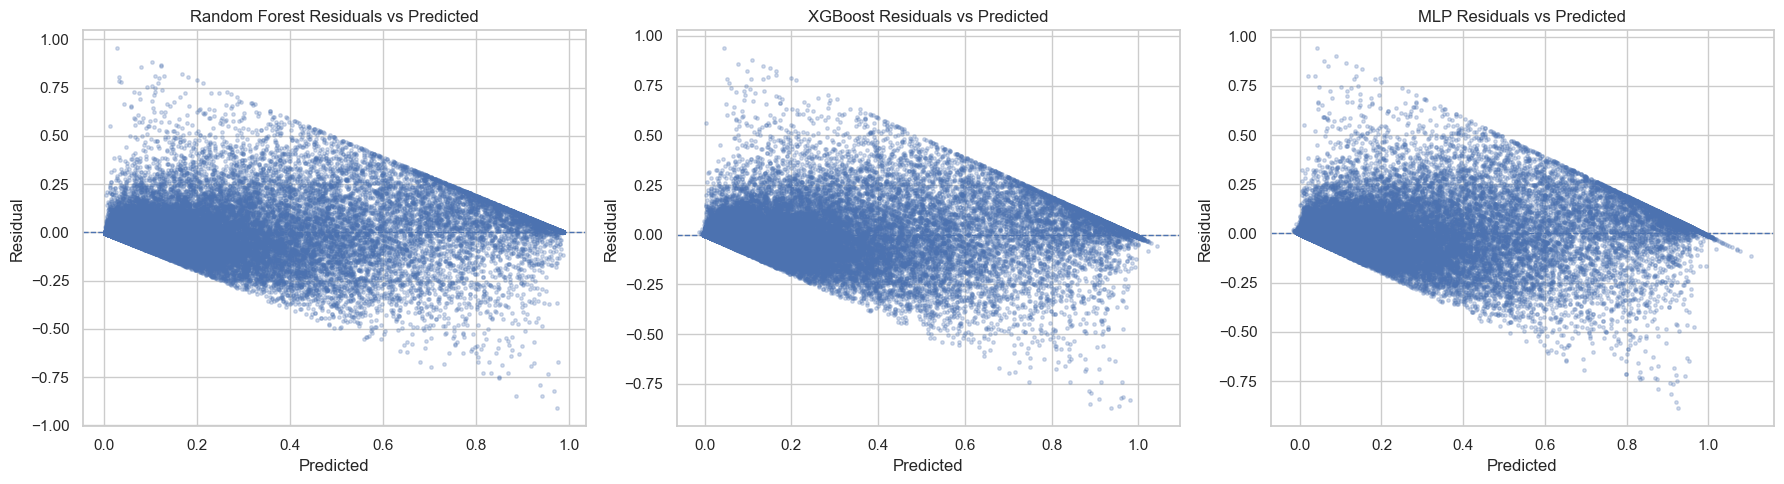

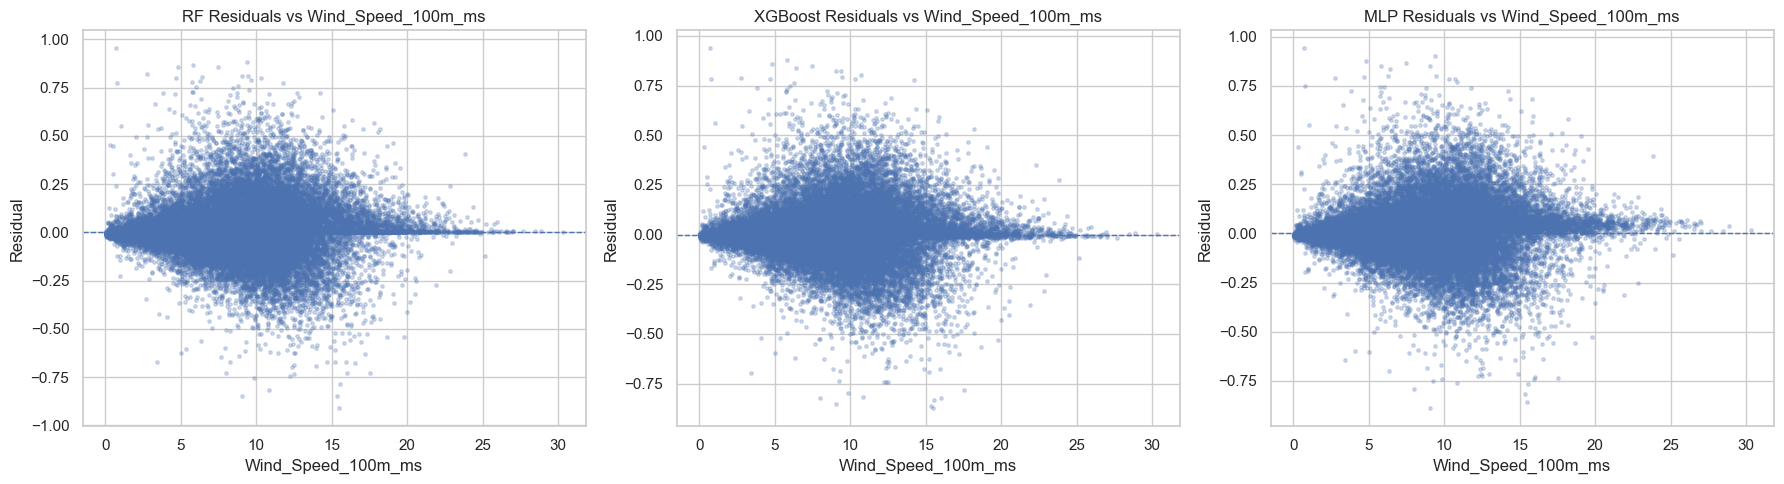

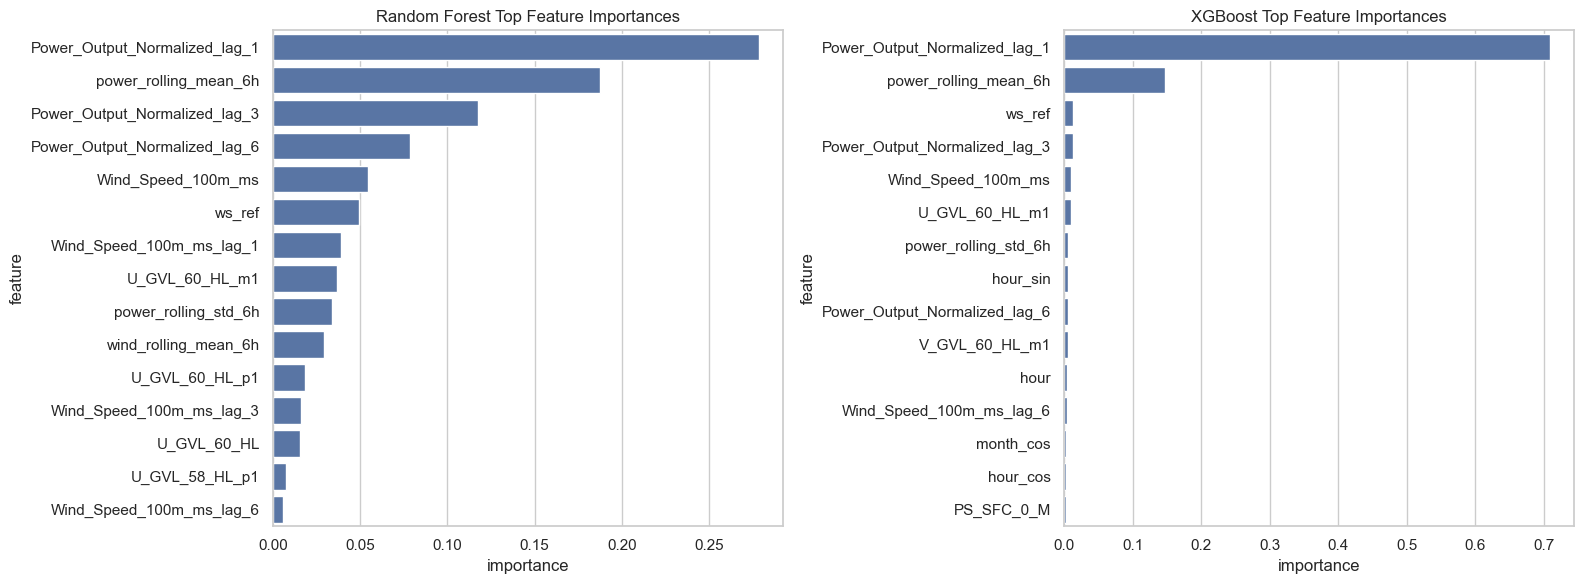

In [16]:
# ============================================================
# NB07 | Residual plots και feature importances
# ============================================================

plot_sample_size = min(50_000, len(diagnostics_df))
plot_df = diagnostics_df.iloc[:plot_sample_size].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(plot_df["Random Forest Pred"], plot_df["Random Forest Residual"], s=6, alpha=0.25)
axes[0].axhline(0.0, linestyle="--", linewidth=1)
axes[0].set_title("Random Forest Residuals vs Predicted")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Residual")

axes[1].scatter(plot_df["XGBoost Pred"], plot_df["XGBoost Residual"], s=6, alpha=0.25)
axes[1].axhline(0.0, linestyle="--", linewidth=1)
axes[1].set_title("XGBoost Residuals vs Predicted")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Residual")

axes[2].scatter(plot_df["MLP Pred"], plot_df["MLP Residual"], s=6, alpha=0.25)
axes[2].axhline(0.0, linestyle="--", linewidth=1)
axes[2].set_title("MLP Residuals vs Predicted")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Residual")

plt.tight_layout()
plt.show()

if selected_wind_feature is not None:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].scatter(plot_df[selected_wind_feature], plot_df["Random Forest Residual"], s=6, alpha=0.25)
    axes[0].axhline(0.0, linestyle="--", linewidth=1)
    axes[0].set_title(f"RF Residuals vs {selected_wind_feature}")
    axes[0].set_xlabel(selected_wind_feature)
    axes[0].set_ylabel("Residual")

    axes[1].scatter(plot_df[selected_wind_feature], plot_df["XGBoost Residual"], s=6, alpha=0.25)
    axes[1].axhline(0.0, linestyle="--", linewidth=1)
    axes[1].set_title(f"XGBoost Residuals vs {selected_wind_feature}")
    axes[1].set_xlabel(selected_wind_feature)
    axes[1].set_ylabel("Residual")

    axes[2].scatter(plot_df[selected_wind_feature], plot_df["MLP Residual"], s=6, alpha=0.25)
    axes[2].axhline(0.0, linestyle="--", linewidth=1)
    axes[2].set_title(f"MLP Residuals vs {selected_wind_feature}")
    axes[2].set_xlabel(selected_wind_feature)
    axes[2].set_ylabel("Residual")

    plt.tight_layout()
    plt.show()

top_k = 15

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=rf_importance_df.head(top_k),
    x="importance",
    y="feature",
    ax=axes[0],
)
axes[0].set_title("Random Forest Top Feature Importances")

sns.barplot(
    data=xgb_importance_df.head(top_k),
    x="importance",
    y="feature",
    ax=axes[1],
)
axes[1].set_title("XGBoost Top Feature Importances")

plt.tight_layout()
plt.show()

## Τελικό verification cell

Το `NB07` θεωρείται methodologically acceptable μόνο αν περάσουν όλα τα παρακάτω:

- canonical benchmark schema / read-back
- presence of all NB07 models exactly once
- canonical prediction export schema
- zero-padded `park_id`
- absence of duplicates
- absence of nulls στα prediction exports
- compatibility με το tidy prediction contract του `NB06`

Αν κάποιος από αυτούς τους ελέγχους αποτύχει, το notebook δεν πρέπει να θεωρείται έτοιμο για handoff προς το `NB08`.

In [18]:
# ============================================================
# NB07 | Final verification 
# ============================================================

verification_checks = []

# 1. Benchmark read-back
benchmark_readback = pd.read_csv(BENCHMARK_PATH)
benchmark_ok = (
    list(benchmark_readback.columns) == BENCHMARK_COLUMNS
    and not benchmark_readback["Model"].duplicated().any()
    and NB07_MODELS.issubset(set(benchmark_readback["Model"].astype(str)))
)
verification_checks.append(("benchmark_readback", benchmark_ok))

# 2. Prediction files existence
prediction_paths = [PRED_RF_PATH, PRED_XGB_PATH, PRED_MLP_PATH, PRED_ALL_PATH]
prediction_files_exist = all(path.exists() for path in prediction_paths)
verification_checks.append(("prediction_files_exist", prediction_files_exist))

# 3. Prediction schema / duplicates / park_id formatting
prediction_contract_ok = True
prediction_debug_rows = []

for path in prediction_paths:
    pred_df = pd.read_csv(
        path,
        dtype={"park_id": "string", "model": "string"},
    )

    # canonical read-back normalization
    pred_df["park_id"] = (
        pred_df["park_id"]
        .astype(str)
        .str.replace(".0", "", regex=False)
        .str.zfill(5)
    )

    pred_df["timestamp"] = pd.to_datetime(pred_df["timestamp"], errors="coerce")

    schema_ok = list(pred_df.columns) == ["park_id", "timestamp", "model", "y_true", "y_pred"]
    park_id_ok = pred_df["park_id"].astype(str).str.len().eq(5).all()
    duplicate_ok = not pred_df.duplicated(subset=["park_id", "timestamp", "model"]).any()
    null_ok = pred_df.isnull().sum().sum() == 0

    file_ok = schema_ok and park_id_ok and duplicate_ok and null_ok
    if not file_ok:
        prediction_contract_ok = False

    prediction_debug_rows.append(
        {
            "file": path.name,
            "schema_ok": schema_ok,
            "park_id_ok": park_id_ok,
            "duplicate_ok": duplicate_ok,
            "null_ok": null_ok,
            "rows": len(pred_df),
        }
    )

verification_checks.append(("prediction_contract_ok", prediction_contract_ok))

# 4. Long export row count consistency
expected_long_rows = len(test_df) * 3
actual_long_rows = pd.read_csv(
    PRED_ALL_PATH,
    dtype={"park_id": "string", "model": "string"},
).shape[0]
long_rows_ok = actual_long_rows == expected_long_rows
verification_checks.append(("long_rows_ok", long_rows_ok))

verification_df = pd.DataFrame(verification_checks, columns=["check", "passed"])
prediction_debug_df = pd.DataFrame(prediction_debug_rows)

display(verification_df)
display(prediction_debug_df)

if not verification_df["passed"].all():
    raise RuntimeError("Το τελικό verification του NB07 απέτυχε. Το notebook ΔΕΝ είναι NB08-ready.")

NB08_READY = True
print("QUICK VERIFICATION PASSED")
print("NB08_READY =", NB08_READY)

,check,passed
0,benchmark_readback,True
1,prediction_files_exist,True
2,prediction_contract_ok,True
3,long_rows_ok,True


,file,schema_ok,park_id_ok,duplicate_ok,null_ok,rows
0,nb07_random_forest_test_predictions.csv,True,True,True,True,1086336
1,nb07_xgboost_test_predictions.csv,True,True,True,True,1086336
2,nb07_mlp_test_predictions.csv,True,True,True,True,1086336
3,nb07_all_test_predictions_long.csv,True,True,True,True,3259008


QUICK VERIFICATION PASSED
NB08_READY = True


In [19]:
# ============================================================
# NB07 | Synchronized thesis-ready conclusion
# Το markdown παράγεται δυναμικά από τα actual rerun outputs.
# ============================================================

ranked = benchmark_after_update.sort_values("MAE", kind="mergesort").reset_index(drop=True)
best_nb07 = nb07_test_metrics_df.iloc[0]
best_overall = ranked.iloc[0]

rf_row = nb07_test_metrics_df.loc[nb07_test_metrics_df["Model"] == "Random Forest"].iloc[0]
xgb_row = nb07_test_metrics_df.loc[nb07_test_metrics_df["Model"] == "XGBoost"].iloc[0]
mlp_row = nb07_test_metrics_df.loc[nb07_test_metrics_df["Model"] == "MLP"].iloc[0]

conclusion_md = f"""
## Συμπεράσματα Notebook 07

Το `NB07` επανεκτελέστηκε ως **strict downstream consumer** των canonical split artifacts του `NB05`,
χωρίς raw reparsing, χωρίς split redefinition και χωρίς αλλαγή upstream preprocessing logic.

### Methodological outcome

- επιβεβαιώθηκε το provenance / integrity contract των `train_final.csv`, `val_final.csv`, `test_final.csv`
- ορίστηκε **ένα κοινό clean numeric feature space** για `Random Forest`, `XGBoost`, `MLP`
- εφαρμόστηκε **validation-only model selection**
- το `test` split χρησιμοποιήθηκε αποκλειστικά για final benchmark reporting
- για το `MLP`, το scaling έγινε leakage-safe με `fit` μόνο στο `train`
- γράφτηκαν canonical tidy prediction exports με zero-padded `park_id`
- το `baseline_metrics.csv` ενημερώθηκε με safe canonical τρόπο
- το τελικό verification cell πέρασε επιτυχώς

### Final NB07 test metrics

- **Random Forest** — MAE: `{rf_row["MAE"]:.6f}`, RMSE: `{rf_row["RMSE"]:.6f}`, R²: `{rf_row["R2"]:.6f}`
- **XGBoost** — MAE: `{xgb_row["MAE"]:.6f}`, RMSE: `{xgb_row["RMSE"]:.6f}`, R²: `{xgb_row["R2"]:.6f}`
- **MLP** — MAE: `{mlp_row["MAE"]:.6f}`, RMSE: `{mlp_row["RMSE"]:.6f}`, R²: `{mlp_row["R2"]:.6f}`

### Interpretation

Το ισχυρότερο advanced baseline του `NB07` στο current rerun είναι το:

- **{best_nb07["Model"]}** με MAE `{best_nb07["MAE"]:.6f}`

Στο συνολικό canonical benchmark artifact, το current best model είναι:

- **{best_overall["Model"]}** με MAE `{best_overall["MAE"]:.6f}`

### Readiness for NB08

Το notebook θεωρείται πλέον **methodologically ready** για handoff προς το `NB08`,
καθώς παρέχει:

- canonical advanced-baseline test predictions
- safe benchmark state
- και diagnostics-ready residual artifacts
"""

display(Markdown(conclusion_md))


## Συμπεράσματα Notebook 07

Το `NB07` επανεκτελέστηκε ως **strict downstream consumer** των canonical split artifacts του `NB05`,
χωρίς raw reparsing, χωρίς split redefinition και χωρίς αλλαγή upstream preprocessing logic.

### Methodological outcome

- επιβεβαιώθηκε το provenance / integrity contract των `train_final.csv`, `val_final.csv`, `test_final.csv`
- ορίστηκε **ένα κοινό clean numeric feature space** για `Random Forest`, `XGBoost`, `MLP`
- εφαρμόστηκε **validation-only model selection**
- το `test` split χρησιμοποιήθηκε αποκλειστικά για final benchmark reporting
- για το `MLP`, το scaling έγινε leakage-safe με `fit` μόνο στο `train`
- γράφτηκαν canonical tidy prediction exports με zero-padded `park_id`
- το `baseline_metrics.csv` ενημερώθηκε με safe canonical τρόπο
- το τελικό verification cell πέρασε επιτυχώς

### Final NB07 test metrics

- **Random Forest** — MAE: `0.070963`, RMSE: `0.118826`, R²: `0.846918`
- **XGBoost** — MAE: `0.065750`, RMSE: `0.113494`, R²: `0.860348`
- **MLP** — MAE: `0.068008`, RMSE: `0.115343`, R²: `0.855760`

### Interpretation

Το ισχυρότερο advanced baseline του `NB07` στο current rerun είναι το:

- **XGBoost** με MAE `0.065750`

Στο συνολικό canonical benchmark artifact, το current best model είναι:

- **XGBoost** με MAE `0.065750`

### Readiness for NB08

Το notebook θεωρείται πλέον **methodologically ready** για handoff προς το `NB08`,
καθώς παρέχει:

- canonical advanced-baseline test predictions
- safe benchmark state
- και diagnostics-ready residual artifacts
